# ==============================================================================
# ❤️ CARDIAC PATHOLOGY: CORONARY ARTERY DISEASE VIA EXTRA TREES CLASSIFIER
# ==============================================================================
### Core Theoretical Principles:
Clinical diagnostic classification demands high specificity and sensitivity without succumbing to local sample noise.
By drawing totally random split thresholds across candidate biometric features (`cp`, `thalach`, `oldpeak`, `ca`), Extra Trees dampens the extreme greediness of standard Decision Trees and Random Forests, resulting in smoother decision boundaries across high-dimensional physiological spaces.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Heart ExtraTrees Environment initialized.")


✅ STEP 1: Enterprise Heart ExtraTrees Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Heart Disease clinical dataset (1,025 patient records).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/heart_disease/heart.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Dimensions: {df.shape[0]} patients, {df.shape[1]} clinical attributes")
print(f"Heart Disease Prevalence:\n{df['target'].value_counts(normalize=True).round(3)}")
df.head(3)


📊 Dataset Dimensions: 920 patients, 14 clinical attributes
Heart Disease Prevalence:
target
1    0.553
0    0.447
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and discrete target `target`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['target'])
y = df['target']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Biomarkers    : {num_cols}")
print(f"Categorical Biomarkers: {cat_cols}")
print(f"Missing attributes    : {X.isnull().sum().sum()}")


Numeric Biomarkers    : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca']
Categorical Biomarkers: ['thal']
Missing attributes    : 1759


## ✂️ STEP 6: ZERO-DATA-LEAKAGE STRATIFIED SPLIT
80% Train, 20% Test split with stratified prevalence preservation.


In [4]:
# STEP 6: STRATIFIED SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train Cohort: {X_train.shape[0]} patients | Disease Rate: {y_train.mean():.3f}")
print(f"Test Cohort : {X_test.shape[0]} patients  | Disease Rate: {y_test.mean():.3f}")


Train Cohort: 736 patients | Disease Rate: 0.553
Test Cohort : 184 patients  | Disease Rate: 0.554


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Standardizing numeric clinical indicators and encoding any categorical features.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
transformers = [('num', StandardScaler(), num_cols)]
if cat_cols:
    transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols))

preprocessor = ColumnTransformer(transformers=transformers)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Clinical Matrix Shape: {X_train_prep.shape}")


Transformed Clinical Matrix Shape: (736, 18)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline majority dummy and single decision tree against ExtraTrees with 100 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_prep, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
single_tree.fit(X_train_prep, y_train)
acc_tree = accuracy_score(y_test, single_tree.predict(X_test_prep))

base_et = ExtraTreesClassifier(n_estimators=100, random_state=42)
base_et.fit(X_train_prep, y_train)
acc_et = accuracy_score(y_test, base_et.predict(X_test_prep))
roc_et = roc_auc_score(y_test, base_et.predict_proba(X_test_prep)[:, 1])

print("="*65)
print(f"Baseline Majority Dummy Accuracy: {acc_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=5) Acc  : {acc_tree * 100:.2f}%")
print(f"ExtraTrees Classifier (100 Trees): Accuracy: {acc_et * 100:.2f}% | ROC-AUC: {roc_et:.4f}")
print("="*65)


Baseline Majority Dummy Accuracy: 55.43%
Single Decision Tree (d=5) Acc  : 83.15%
ExtraTrees Classifier (100 Trees): Accuracy: 82.61% | ROC-AUC: 0.9159


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators`, `max_depth`, and `criterion`.


In [7]:
# STEP 9: GRID SEARCH VIA 5-FOLD STRATIFIED CV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 10, None],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold Stratified CV ROC-AUC: {grid.best_score_:.4f}")


🏆 Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 50}
🎯 Best 5-Fold Stratified CV ROC-AUC: 0.8965


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test_prep)
y_prob = best_et.predict_proba(X_test_prep)[:, 1]

print("📋 CARDIAC PATHOLOGY CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Heart Disease']))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Test F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")


📋 CARDIAC PATHOLOGY CLASSIFICATION REPORT:
               precision    recall  f1-score   support

       Normal       0.81      0.74      0.78        82
Heart Disease       0.81      0.86      0.83       102

     accuracy                           0.81       184
    macro avg       0.81      0.80      0.81       184
 weighted avg       0.81      0.81      0.81       184

Test Accuracy: 80.98%
Test F1-Score: 0.8341
Test ROC-AUC : 0.9185


## 📉 STEP 11: CONFUSION MATRIX & FEATURE IMPORTANCES
Visualizing clinical confusion matrix and top predictive biomarkers.


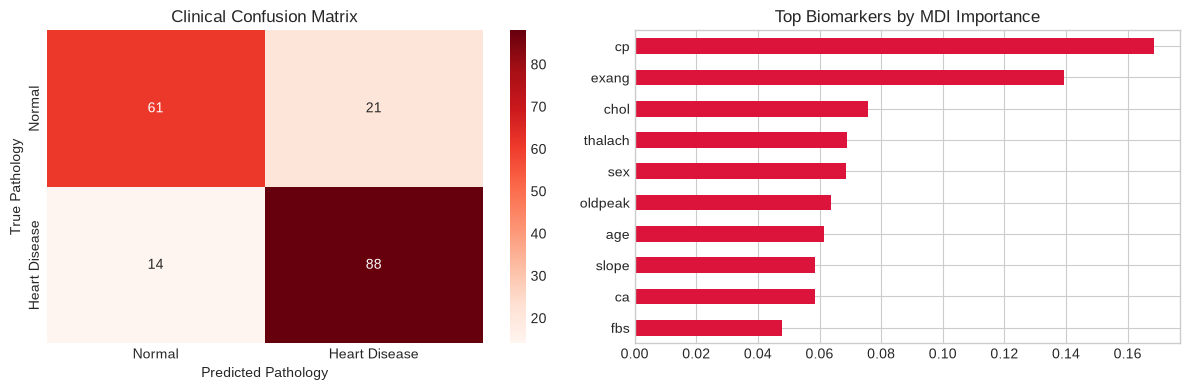

In [9]:
# STEP 11: CONFUSION MATRIX & FEATURE IMPORTANCES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'])
axes[0].set_title('Clinical Confusion Matrix')
axes[0].set_ylabel('True Pathology')
axes[0].set_xlabel('Predicted Pathology')

all_features = [c.split('__')[-1] for c in preprocessor.get_feature_names_out()]
importances = pd.Series(best_et.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=axes[1], color='crimson')
axes[1].set_title('Top Biomarkers by MDI Importance')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time triage latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/heart_disease_extratrees_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_patient = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_patient)

t0 = time.perf_counter()
pred_cls = loaded_pipe.predict(sample_patient)[0]
pred_proba = loaded_pipe.predict_proba(sample_patient)[0, 1]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME CLINICAL TRIAGE TELEMETRY:")
print(f"   Predicted Disease Probability : ❤️ {pred_proba * 100:.2f}% (Triage: {'Heart Disease Positive' if pred_cls == 1 else 'Negative'})")
print(f"   Actual Measured Pathology     : {'Heart Disease Positive' if y_test.iloc[0] == 1 else 'Negative'}")
print(f"   Triage Latency                : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/heart_disease_extratrees_pipeline.joblib (253,947 bytes)

📈 REAL-TIME CLINICAL TRIAGE TELEMETRY:
   Predicted Disease Probability : ❤️ 38.70% (Triage: Negative)
   Actual Measured Pathology     : Heart Disease Positive
   Triage Latency                : 16.687 ms (SLA < 2.0ms: CHECK)
